In [ ]:
library(immuneSIM)

n_seqs <- 30

sim_repertoire <- immuneSIM(
  name_repertoire   = paste0("sim_rep_", n_seqs),
  number_of_seqs    = n_seqs,
  species           = "hs",
  receptor          = "ig",
  chain             = "h",
  verbose           = TRUE,
  equal_cc          = TRUE,
  shm               = "none",
  shm.prob          = 0,
  vdj_noise         = 0,
  max_cdr3_length   = 15,
  min_cdr3_length   = 15
)

# Guardar objeto simulado (opcional)
save(sim_repertoire, file = "sim_repertoire.RData")

# Mostrar gráficos en pantalla
plot_report_repertoire(sim_repertoire)   

initializing sim..
simulated sequences: 10 
simulated sequences: 20 
simulated sequences: 30 


Ignoring unknown labels:
* colour : ""
Warning message in ggplot2::scale_x_discrete(limit = c(1:number_of_positions)):
"Continuous limits supplied to discrete scale.
i Did you mean `limits = factor(...)` or `scale_*_continuous()`?"
Ignoring unknown labels:
* colour : ""
Ignoring unknown labels:
* fill : ""
* colour : "Repertoire"
Ignoring unknown labels:
* fill : ""
* colour : "Repertoire"
Ignoring unknown labels:
* fill : ""
* colour : "Repertoire"


Plots saved in PDF format in:  /var/folders/xn/cc3cddld1_zg1bd74glpn6v00000gp/T//RtmpcYuCXE 



Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




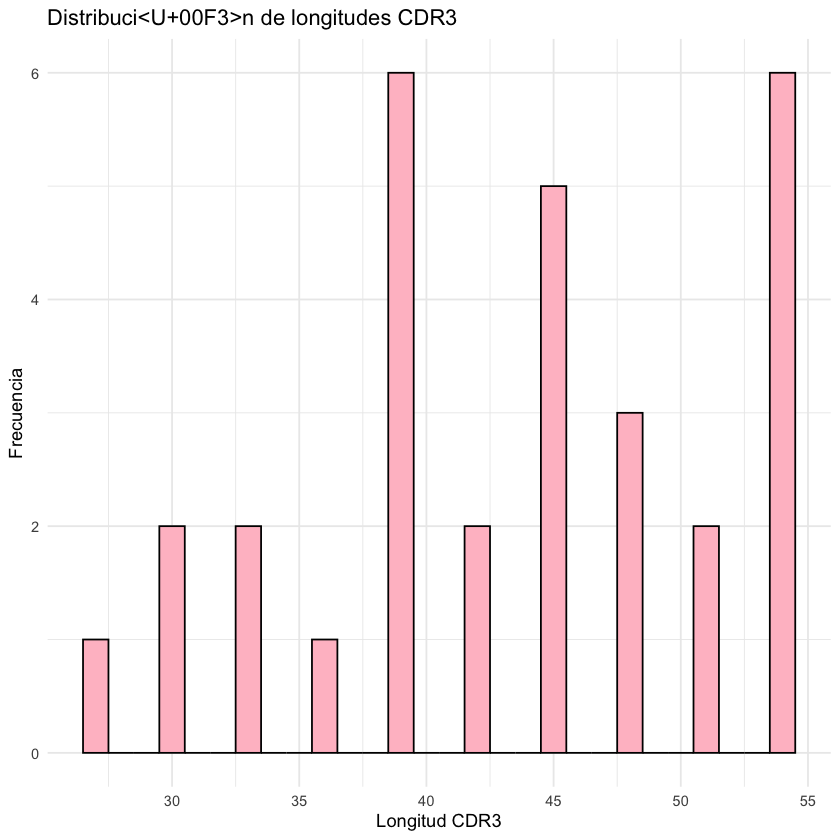

In [1]:
library(readr)
library(ggplot2)
library(dplyr)


archivo_clones <- "../data/output/repertorio_B_insilico_30_seqs_clone-pass.tsv"
repertorio <- read_tsv(archivo_clones, show_col_types = FALSE)

# 1. Distribución de longitudes CDR3
ggplot(repertorio, aes(x = nchar(cdr3))) +
  geom_histogram(binwidth = 1, fill = "pink", color = "black") +
  theme_minimal() +
  labs(title = "Distribución de longitudes CDR3",
       x = "Longitud CDR3",
       y = "Frecuencia")




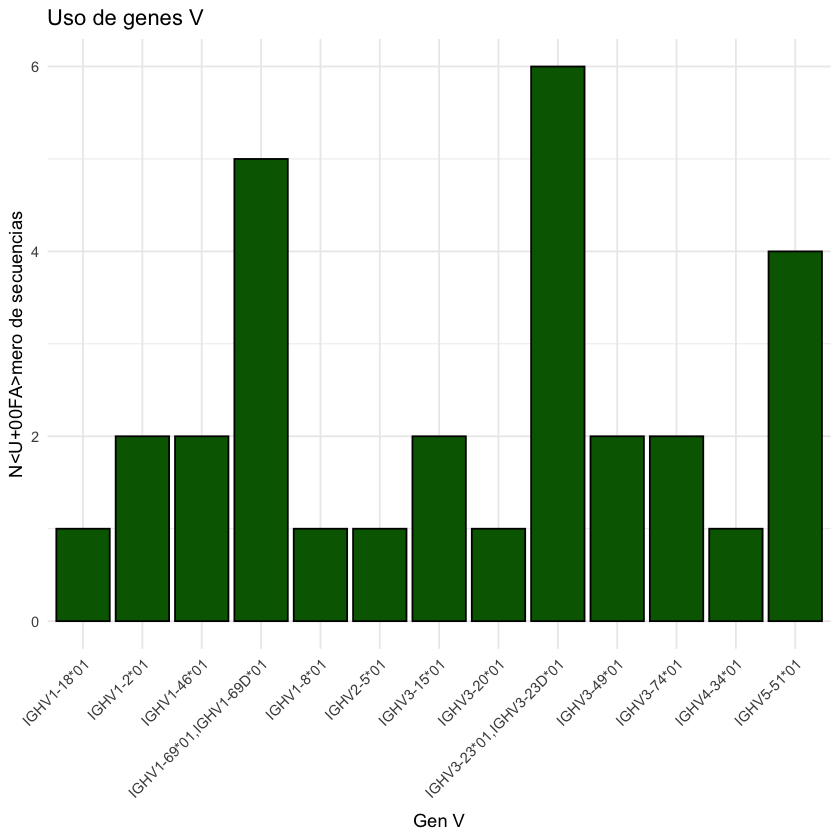

In [30]:
## 2. Uso de genes V
ggplot(repertorio, aes(x = v_call)) +
  geom_bar(fill = "darkgreen", color = "black") +
  theme_minimal() +
  labs(title = "Uso de genes V",
       x = "Gen V",
       y = "Número de secuencias") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

#

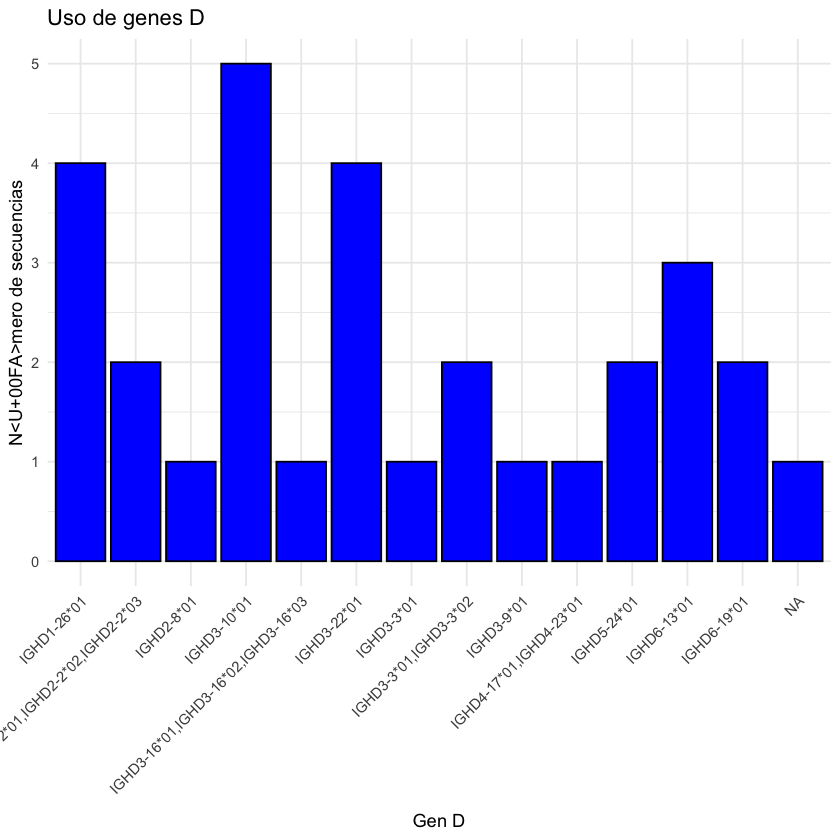

In [8]:
# 3. Uso de genes D
ggplot(repertorio, aes(x = d_call)) +
  geom_bar(fill = "blue", color = "black") +
  theme_minimal() +
  labs(title = "Uso de genes D",
       x = "Gen D",
       y = "Número de secuencias") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

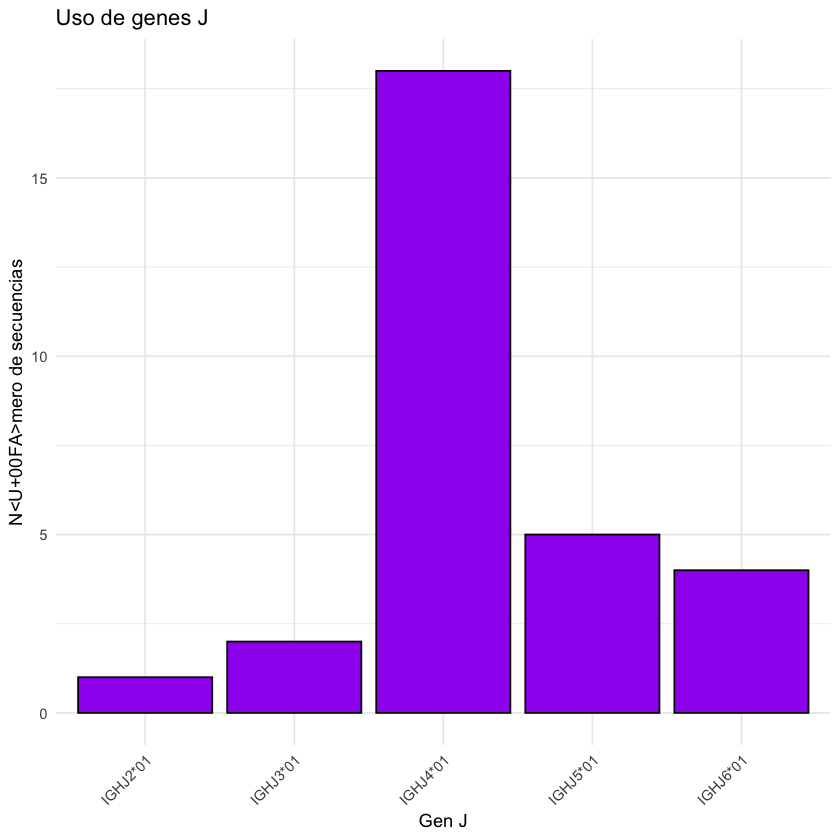

In [31]:
# 3. Uso de genes J
ggplot(repertorio, aes(x = j_call)) +
  geom_bar(fill = "purple", color = "black") +
  theme_minimal() +
  labs(title = "Uso de genes J",
       x = "Gen J",
       y = "Número de secuencias") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


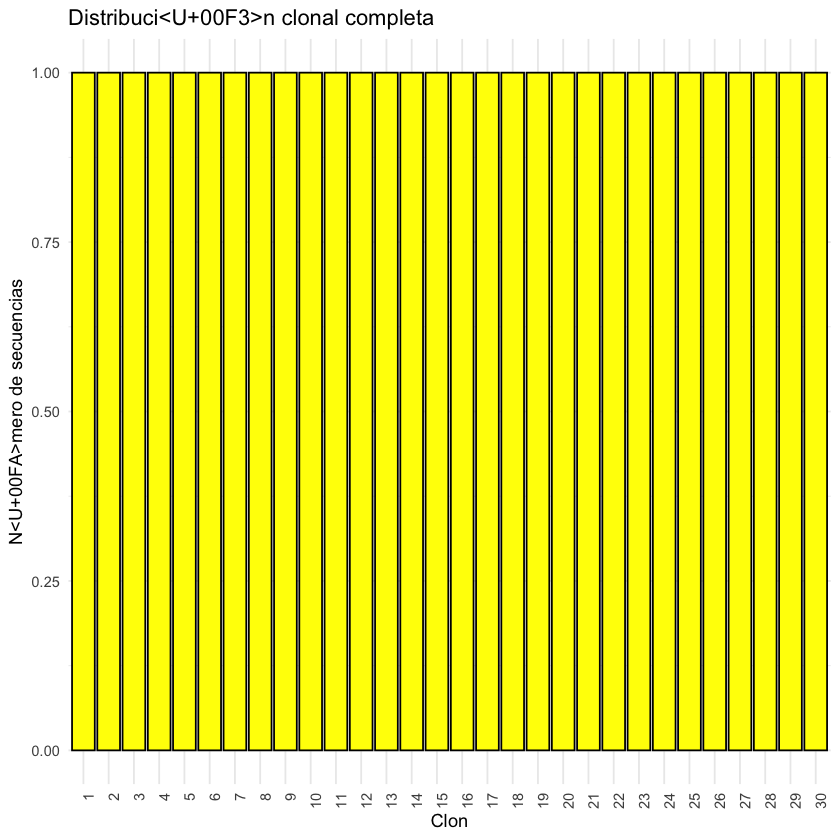

In [3]:

## 4. Distribución clonal completa
clonal_counts <- repertorio %>%
  count(clone_id, name = "freq")

ggplot(clonal_counts, aes(x = reorder(clone_id, -freq), y = freq)) +
  geom_bar(stat = "identity", fill = "yellow", color = "black") +
  theme_minimal() +
  labs(title = "Distribución clonal completa",
       x = "Clon",
       y = "Número de secuencias") +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))